# A model workflow for IMEX Shallow Flow

IMEX is a highly versatile liquid simulation model, with some specialized parameters for various flow compositions. In this case, we have configured the model to simulate PDCs.

In [1]:
import rioxarray as rxr
import xarray as xr
import subprocess
import numpy as np  
import matplotlib.pyplot as plt
import subprocess
from netCDF4 import Dataset
import cartopy.crs as ccrs
import pyproj
import netCDF4
import sys
import shutil

In [2]:
sys.path.insert(0,"/home/jovyan/shared/Libraries")
import victor

In [3]:
savefig = True

### First, we must create the pyroclastic avalanche.

The avalanche is computed as a niche obtained by the intersection of the topograpgy and an ellipsoid, defined by two points (x1,y1) (x2,y2) and a semi-axis. The two points in the x-y plane are the coordinates of the lowest and highest point of the initial volume, which also define two semi-axis of the ellipsoid. The length of the third semi-axis is provided by the user. The concavity of the niche is searched automatically to match the desired volume.

In [4]:
DEM_folder = './'
DEM_file = 'colima.asc'

x1 = 644900
y1 = 2157930

x2 = 645030
y2 = 2158060

semi_width = 55 

center = np.array([(x1+x2)/2, (y1+y2)/2])

vol = 250000

In [5]:
f = open("input_ellipsoid.py",'w')
f.write(f'''DEM_folder = "{DEM_folder}"
DEM_file = "{DEM_file}"
x1 = {x1}
y1 = {y1}
x2 = {x2}
y2 = {y2}
semi_width = {semi_width}
vol = {vol}''')
f.close()

In [6]:
!python create_input_ellipsoid.py


----------------------------------------------
Pre-processing tool by M. de' Michieli Vitturi
----------------------------------------------

Reading DEM file: ./colima.asc
/home/jovyan/IMEX_SfloW_2D/DEM/create_input_ellipsoid.py:323: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  DEM = pd.read_table(DEM_file,
Completed reading DEM, shape: (900, 900)

semi_axis0 41.91347983049358
Ellissoid center: 644900 2157930 3761.1513864556955
Ellipsoid semi-axis:  41.91347983038054 41.91347983049358 43.12385960022675
Rotation angle:  36.25383773764157
Initial volume 19340.449962852483  m3
semi_axis2 167.6539193219743
Ellissoid center: 644900 2157930 3867.3373948502635
Ellipsoid semi-axis:  167.65391932211247 167.6539193219743 149.30986799479479
Rotation angle:  41.42366562497282
Initial volume 823101.0580653771  m3
semi_axis1 124.85205079819556
Ellissoid center: 644900 2157930 3833.559394564098
Elli

### In the following sections, we will provide a variety of input information, including topographical, rheological and thermal parameters.

### First, you must enter the run name, along with some time constraints and flags to determine the kind of output they would like to produce.

In [8]:
#prefix for output files
run_name = "Colima"

#starting a run from a previous output (T/F)
restart = 'T'

#Starting simulation time, recommended is 0
t_start = 0

#End simulation time
t_end = 100

#Delta time between output snapshots
dt_output = 5

#Flags for output of conservation, esri ascii DEM, and max runout at each dt (T/F)
cons, esri, runout = 'F','T','F'

#Select verbose level (0 recommeneded)
verbose_level = 0

### Here the user sets the parameters for a radial source. Need to provide its location, size, lava velocity, temperature, and duration of effusion.

In [16]:
dem = rxr.open_rasterio("".join([DEM_folder,DEM_file]))
#UTM x coordinate
x_source=644956

#UTM y coordinate
y_source=2157970

#Number of solid classes
n_solid = 1 

#Number of additional gas components
n_add_gas = 0

coordinates = np.array([x_source, y_source])

### Here, the user may input additional parameters to specify granularity of each cell

The current values are set to popular values at a reasonable granularity, though users are welcome to make changes.
Additional flags to incorporate more detailed parameters into the model are also offered here.

In [9]:
#set size of cells im m^2
cell_size = int(dem.rio.resolution()[0])

#set x_0 and y_0 in UTM
x0, y0 = int(dem.rio.bounds()[0])+int(dem.rio.resolution()[0]), int(dem.rio.bounds()[1])+int(dem.rio.resolution()[0])

#set number of cells on x and y axes
cells_x, cells_y = dem.rio.shape[0]-5, dem.rio.shape[1]-5

#set flags for additional rheology and energy information
rheo, energy= 'T', 'F'

#Set topography to change with deposiiton
topo_change = 'F'

#choose at least one between liquid flag and gas flag
liquid, gas = 'F', 'T'

#set alpha for the linear reconstruction and the boundary condition
# T  => alpha 
# F  => h*alpha
alpha = 'T'

#correct topography slope when computing pressure forces
# T => correction active
# F => correction not active
subtract_init = 'F'

#set additional flags for radial source, bottom radial source, and collapsing volume
radial, bottom_radial, collapsing= 'F','F','F'


### Below, set the numerical parameters. 

These parameters impact the stability of the solution, and should be handled carefully.

In [10]:
#Setting solver scheme (choose from LxF, GFORCE, KT)
#'LxF'       => lax-friedrichs scheme;
#'GFORCE '   => gforce scheme;
#'KT'        => Kurganov and Tadmor semidiscrete scheme;
solver_sceme = "\"KT\""

#set cfl (Courant-Friedrichs-Lewy parameter)
cfl = .24

#set limiter (for the slope in the linear reconstruction)
limiter = "5*3"

# Van Leer limiter parameter
theta = 1.3

#set slope coeffiecient for the linear reconstruction
reconstr_coeff = 1

#order of Runge-Kutta
n_rk = 2

### Gravity in $m/s^2$. Change if running for another planet or moon.

In [11]:
#set gravity (in case of non terran modeling)
grav = 9.81

### Below, the user should enter rheological parameters

We provide convenient defaults, though currently support only Voellmy-Salm and the Bursik/Woods model.

In [12]:
#set model used (1=Voellmy-Salm,2=plastic,3=using reference kinematic viscosity, viscosity param,yield strength (nu_ref/visc_par/tau0),
#4=simplified with fewer params  5=Kurganov & Petrova,6=Bursik * Woods)
rheology_model = 1

#Friction factor (Bursik/Woods)

friction_factor = 1e-3

#drag coefficients (Voellmy-Salm model) 
mu = .5

xi = 300

### Below, Please enter solid transport parameters

In [13]:
#Density of particles
rho_s = 2000

#Diameter of particles
diam_s = 1.0e-3

#Specific heat of solids
sp_heat_s = 1617

#Flag to determine if sedimentation is active. 
settling = 'F'

#erosion model coefficient (units: m-1 ) 
erosion_coeff = 0

### If the flag is set, the user can input parameters for gas, useful in a degassing situation.

If the flag is not set, the user can skip this cell, and does not need to delete it.

In [14]:
#Specific heat of air (units: J K-1 kg-1)
sp_heat_a = 998

#Specific gas constant of air (units: J kg-1 K-1)
sp_gas_const_a = 287.051

#Kinematic viscosity of air (units: m2 s-1) (10^-5 scale)
kin_visc_a = 1.48

#Kinematic viscosity of air (units: m2 s-1)
pres = 101300

#Kinematic viscosity of air (units: m2 s-1)
t_ambient = 300

# activate air entrainment 
entrainment = 'F'

### The next four cells can be run without further input. 

We have set up the correct input format and will run the model for you. Please wait until the final of the four cells prints to continue.

In [15]:
the_rest = f'''&RUN_PARAMETERS
 RUN_NAME="{run_name}",
 RESTART={restart},
 T_START=  {t_start}     ,
 T_END=  {t_end},
 DT_OUTPUT=  {dt_output},
 OUTPUT_CONS_FLAG={cons},
 OUTPUT_ESRI_FLAG = {esri} ,
 OUTPUT_PHYS_FLAG=T,
 OUTPUT_RUNOUT_FLAG={runout},
 VERBOSE_LEVEL={verbose_level},
 /
&NEWRUN_PARAMETERS
 X0={x0}.0D0,
 Y0=  {y0}.0D0     ,
 TOPOGRAPHY_FILE = './new_dem.asc' ,
 COMP_CELLS_X=  {cells_x},
 COMP_CELLS_Y=  {cells_y},	
 CELL_SIZE = {cell_size}.D0    ,
 N_SOLID = {n_solid} ,
 N_ADD_GAS = {n_add_gas} ,
 RHEOLOGY_FLAG = {rheo} ,
 ENERGY_FLAG = {energy},
 TOPO_CHANGE_FLAG = {topo_change},
 GAS_FLAG = {gas},
 LIQUID_FLAG = {liquid}, 
 RADIAL_SOURCE_FLAG = {radial},
 BOTTOM_RADIAL_SOURCE_FLAG = {bottom_radial},
 COLLAPSING_VOLUME_FLAG = {collapsing} ,
 ALPHA_FLAG = {alpha} ,
 SUBTRACT_INIT_FLAG = {subtract_init} ,
 /
&RESTART_PARAMETERS
 RESTART_FILES ="./init_volume.asc" ,
 T_INIT = 373.D0 ,
 T_AMBIENT = 300.D0 ,
 SED_VOL_PERC = 50.0  ,
/ 
&WEST_BOUNDARY_CONDITIONS
 H_BCW%FLAG=          1,
 H_BCW%VALUE=  0.0000000000000000     ,
 HU_BCW%FLAG=          1,
 HU_BCW%VALUE=  0.0000000000000000     ,
 HV_BCW%FLAG=          1,
 HV_BCW%VALUE=  0.0000000000000000     ,
 ALPHAS_BCW%FLAG= 1,
 ALPHAS_BCW%VALUE=  0.D0     ,
 T_BCW%FLAG=          1,
 T_BCW%VALUE=  0.0000000000000000     ,
 /
&EAST_BOUNDARY_CONDITIONS
 H_BCE%FLAG=          1,
 H_BCE%VALUE=  0.0000000000000000     ,
 HU_BCE%FLAG=          1,
 HU_BCE%VALUE=  0.0000000000000000     ,
 HV_BCE%FLAG=          1,
 HV_BCE%VALUE=  0.0000000000000000     ,
 ALPHAS_BCE%FLAG= 1,
 ALPHAS_BCE%VALUE=  0.D0     ,
 T_BCE%FLAG=          1,
 T_BCE%VALUE=  0.0000000000000000     ,
 /
&SOUTH_BOUNDARY_CONDITIONS
 H_BCS%FLAG=          1,
 H_BCS%VALUE=  0.0000000000000000     ,
 HU_BCS%FLAG=          1,
 HU_BCS%VALUE=  0.0000000000000000     ,
 HV_BCS%FLAG=          1,
 HV_BCS%VALUE=  0.0000000000000000     ,
 ALPHAS_BCS%FLAG= 1,
 ALPHAS_BCS%VALUE=  0.D0     ,
 T_BCS%FLAG=          1,
 T_BCS%VALUE=  0.0000000000000000     ,
 /
&NORTH_BOUNDARY_CONDITIONS
 H_BCN%FLAG=          1,
 H_BCN%VALUE=  0.0000000000000000     ,
 HU_BCN%FLAG=          1,
 HU_BCN%VALUE=  0.0000000000000000     ,
 HV_BCN%FLAG=          1,
 HV_BCN%VALUE=  0.0000000000000000     ,
 ALPHAS_BCN%FLAG= 1,
 ALPHAS_BCN%VALUE=  0.D0     ,
 T_BCN%FLAG=          1,
 T_BCN%VALUE=  0.0000000000000000     ,
 /
&TEMPERATURE_PARAMETERS
 /
&NUMERIC_PARAMETERS
 SOLVER_SCHEME={solver_sceme},
 DT0 = 1.0E-2
 MAX_DT=  10.0000000000000000E-000,
 CFL= {cfl},
 LIMITER= {limiter},
 THETA=  {theta}     ,
 RECONSTR_COEFF=  {reconstr_coeff},
 N_RK= {n_rk},
 /
&EXPL_TERMS_PARAMETERS
 GRAV= {grav},
 /
&RHEOLOGY_PARAMETERS
 RHEOLOGY_MODEL = {rheology_model},\n'''
if rheology_model == 6:
     the_rest = "".join([the_rest, f''' FRICTION_FACTOR = {friction_factor},\n'''])
elif rheology_model == 1:
     the_rest = "".join([the_rest, f''' MU = {mu},
 XI = {xi}\n'''])
the_rest = "".join([the_rest, f''' /
&RUNOUT_PARAMETERS
 DT_RUNOUT = 1.0,
 EPS_STOP = 0.0
/
&SOLID_TRANSPORT_PARAMETERS
 RHO_S = {rho_s}.D0 ,
 DIAM_S = {diam_s},
 SP_HEAT_S = {sp_heat_s}.D0 , 
 SETTLING_FLAG = {settling} ,
 EROSION_COEFF = {erosion_coeff}.D0 ,
 /
&GAS_TRANSPORT_PARAMETERS
 SP_HEAT_A = {sp_heat_a}.D0 ,
 SP_GAS_CONST_A = {sp_gas_const_a}D0 ,
 KIN_VISC_A = {kin_visc_a}D-5 ,
 PRES = {pres}.D0 ,
 T_AMBIENT = {t_ambient}.D0 ,
 ENTRAINMENT_FLAG = {entrainment} ,
 /
&RUNOUT_PARAMETERS
 DT_RUNOUT = 300 ,
 EPS_STOP = 5.D-4 ,
 /
&VULNERABILITY_TABLE_PARAMETERS
 THICKNESS_LEVELS0 = 0.0 , 0.1 , 0.5 , 1.0 , 2.0 , 5.0 
 DYN_PRES_LEVELS0 = 0.0 , 1000.0 , 10000.0 , 50000.0 , 100000.0
 /
 '''])

In [16]:
f = open("IMEX_SfloW2D.inp",'w')
f.write(the_rest)
f.close()

Now we run the Model! Please note: If the models finishes very quickly it is likely spitting out an error mesage. comment out the last parameter to see what comes out oun STDOUT. 

In [17]:
subprocess.run("../IMEX_SfloW2D", shell=True)

 ---------------------
 IMEX_SfloW2D 1.0
 ---------------------
 OpenMP program
 Number of threads used           4
 Run name: Colima                                  
 ----- 2D SIMULATION -----
 CARRIER PHASE: gas
 Carrier phase kinematic viscosity:   1.47999999E-05
 Ambient density =    1.17632997      (kg/m3)

 Initial erodible thickness set to 0

 Model variables =            5
 INITIAL VOLUME FRACTION OF SOLIDS:  0.500000000    
 Linear reconstruction and b. c. applied to variables:
 h,hu,hv,T,alphas
 Searching for DEM file
 Reading DEM file
 ncols         900
 nrows         900
 Percent Complete: 100.00% 
 thickness_levels           6   0.00000000      0.100000001      0.500000000       1.00000000       2.00000000       5.00000000    
 dyn_pres_levels           5   0.00000000       1000.00000       10000.0000       50000.0000       100000.000    
 Searching for probes coords
 Implicit equations =           2
 ALLOCATION OF ARRAYS COMPLETED
 n_restart_files           1

 Restart: 

CompletedProcess(args='../IMEX_SfloW2D', returncode=0)

### Now that everything has run, we have a variety of outputs to utilize. 

The cell below will explain the options and allow you to select a timestep and choose between temperature and flow depth.

In [9]:
num_times = int(np.ceil(t_end/dt_output)+1)
print("Based on the end time and intervals given, there are",num_times,"timesteps available to visualize, starting at 0 (0-"+str(num_times-1)+"). Please enter a number below.")

Based on the end time and intervals given, there are 21 timesteps available to visualize, starting at 0 (0-20). Please enter a number below.


### After entering a number in the valid range, run the rest of the cells.

After a few moments, you will see two plots displaying flow depth and temperature profiles at the given time. Additionally, two neatly formatted netCDF files with the full time series will be output to the current folder.

In [10]:
step = "20"

In [11]:
time_series = []
time_series_temp = []
for i in range(num_times):
    steps = str(i)
    steps = steps.zfill(4)
    filename = "./"+run_name
    filename_temp = "./"+run_name
    filename += "_"+steps+".asc"
    filename_temp += "_T"+"_"+steps+".asc"
    time_series.append(rxr.open_rasterio(filename).drop_vars('band')[0])
    time_series_temp.append(rxr.open_rasterio(filename).drop_vars('band')[0])

In [12]:
step = step.zfill(4)
filename = "./"+run_name
filename_temp = "./"+run_name
filename += "_"+step+".asc"
filename_temp += "_T"+"_"+step+".asc"

In [13]:
times = xr.concat(time_series,dim="time")
times_temp = xr.concat(time_series_temp,dim="time")
ds = times.to_dataset(name='elevation')
ds_temp = times_temp.to_dataset(name='temperature')
ds.to_netcdf("IMEX.nc")
ds.close()
ds_temp.to_netcdf("IMEX_temp.nc")
ds_temp.close()

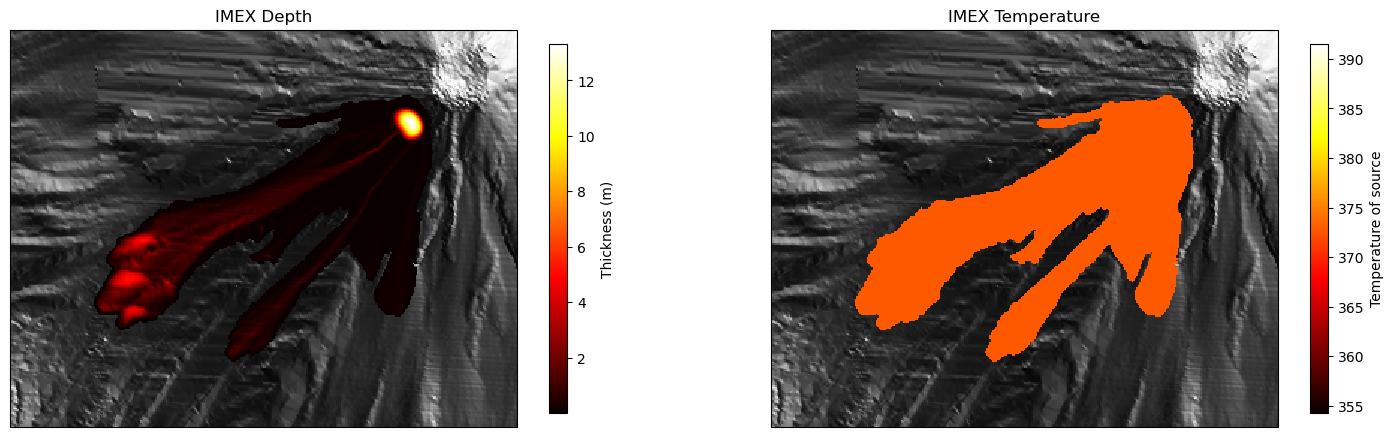

In [22]:
fig, (axd, axt) = plt.subplots(1,2, figsize=(18,8),subplot_kw=dict(projection=ccrs.epsg(32628)))

dem_name = "".join([DEM_folder,DEM_file])

victor.plot_flow(dem_name, filename, axes=axd, coords=coordinates)

axd.set_title("IMEX Depth")

victor.plot_flow(dem_name, filename_temp , axes=axt, coords=coordinates,label="Temperature of source")

axt.set_title("IMEX Temperature")

if savefig:
    plt.savefig("IMEX.png")